<a href="https://colab.research.google.com/github/BeraSourav/App/blob/main/MBE_Production_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
qw_cum_list = []
qw_rate_list = [1,qw_con]
pressure_list = [P_i]
Z_hy_list = []
miu_g_list = []
Bg_list=[]
phi_list=[]
K_list = []
Sw_list = []
Cs_list=[]
tau_d_list = []
ct_list=[]
krw_list=[]
krg_list=[]
qg_list=[]
qtotal_list=[]
lamda_rt_list=[]
lamda_t_list=[]
t_adj_list=[0]
tp_list=[0]
# delta_t_list = []
avg_tp_delta_t_list=[]
integ_tp_list=[0]
tsudo_list = []
tsudo_total_list=[0]
Pai_Pa_list = [0]
alpha_ph_lmrt_list=[]
alpha_ph_lmrt_avg_list=[]
int_alpha_phi_dp_list=[]
qg_scmd_list=[]
delta_pa_inflw_list=[]
pwf_list=[]

We_list = [0]
td_list = [0]
pd_list = [0]

dpdtd_list = [0]

a_aq_list = [0]
b_aq_list = [0]

qw_list = [] ## aquifer

avg_tp_list=[]
delta_pa_list=[]
delta_p_list=[]
P2_list=[P_i]
cg_list = []
del_z_del_p_list=[]
sg_list=[]
# qg_total_list=[]


for j,i in enumerate(range(0,2011,int(dt))):

    B = 1.119*(encrohment_angle/360)*K_i*h*phi_i*(cw+Cf)*(re**2)

    qw_cum = cumulative_water(qw,i)
    qw_cum_list.append(qw_cum)

    pressure = pressure_list[j]

    # print(pressure)
    Z_hy=z_cal(pressure)
    Z_hy_list.append(Z_hy)


    del_z_del_p = del_z_del_p_cal(pressure)
    del_z_del_p_list.append(del_z_del_p)


    # if j>0:
        # cg = Cg_cal(Z_hy_list[j-1],Z_hy_list[j],pressure_list[j-1],pressure_list[j])
    cg = cg_cal(pressure_list[j],Z_hy_list[j],del_z_del_p_list[j])
    cg_list.append(cg)
    # else:
    #     cg_list.append(cg_0)


    # miu_g = miu_g_cal(T,s_g,pressure_list[j],Z_hy_list[j])
    miu_g = miug_cal(pressure)
    miu_g_list.append(miu_g)


    Bg=Bg_cal(Z_hy_list[j],T,pressure)
    Bg_list.append(Bg)


    phi = phi_cal(phi_i,Am,pressure,P_i,e_L,PL,K_M)
    phi_list.append(phi)

    td_list.append(cal_dim_time(i,K_list[j],phi_list[j],miu_w,cw,Cf,re))

    pd_list.append(cal_dim_pressure(td_list[j]))

    dpdtd_list.append(cal_dpdtd(td_list[j],pd_list[j],td_list[j+1],pd_list[j+1]))

    a_aq_list.append(cal_a_aquifer(B,P_i,pressure_list[j],td_list[j+1],td_list[j],pd_list[j+1],j+1,j,We_list[j],dpdtd_list[j]))

    b_aq_list.append(cal_b_aquifer(B,td_list[j+1],td_list[j],pd_list[j+1],j+1,j,dpdtd_list[j]))

    qw_list.append(a_aq_list[j] + b_aq_list[j] * (pressure_list[j] - pressure_list[j-1]))

    We_list.append(We_list[j]+qw_list[j]*(dt))


    Sw=saturation_cal(Sw_i,cw,P_i,pressure,Bw,We_list[j],qw_cum_list[j],A,h,phi_list[j],phi_i)
    Sw_list.append(Sw)
    sg_list.append(1-Sw)

    K=perm_cal(phi_i,phi_list[j],K_i,n)
    K_list.append(K)

    Cs=cs_cal(Bg_list[j],Rho_b,VL,PL,pressure,phi_list[j])
    if j>0:
        Cs_list.append(Cs)
    else:
        Cs_list.append(0)

    tau_d = tau_d_cal(tau,i)
    if j>0:
        tau_d_list.append(tau_d)
    else:
        tau_d_list.append(1)

    ct=Ct_cal(Cf,cw,Sw_list[j],cg_list[j],Cs_list[j],tau_d_list[j])
    ct_list.append(ct)

    krw=krw_cal(Sw_list[j],krwe,Swc,Sgc,nw)
    krw_list.append(krw)

    krg=krg_cal(Sw_list[j],krge,Swc,Sgc,ng)
    krg_list.append(krg)

    qg=qg_cal(qw,krg_list[j],krw_list[j],miu_g_list[j],miu_w,Bg_list[j],Bw)
    qg_list.append(qg)
    qg_scmd_list.append(qg/35.31)


    qtotal = q_total_cal(qg_list[j],qw,Bg_list[j],Bw)
    qtotal_list.append(qtotal)

    lamda_rt=lambda_rt_cal(krw_list[j],miu_w,krg_list[j],miu_g_list[j])
    lamda_rt_list.append(lamda_rt)

    lamda_t =lambda_t_cal(lamda_rt_list[j],K_list[j])
    lamda_t_list.append((lamda_t))

    tp=tp_cal(lamda_rt_list[j],ct_list[j],qtotal_list[j],n,phi_list[j])
    tp_list.append(tp)

    tp_avg=tp_avg_cal(tp_list[j],tp_list[j+1])
    avg_tp_list.append(tp_avg)

    avg_tp_delta_t = avg_tp_delta_t_cal(avg_tp_list[j],dt)
    avg_tp_delta_t_list.append(avg_tp_delta_t)

    int_tp = int_tp_cal(integ_tp_list[j],avg_tp_list[j])
    integ_tp_list.append(int_tp)

    tsudo = tpseudo_cal(lamda_rt_list[j],qtotal_list[j],ct_list[j],avg_tp_delta_t_list[j])
    tsudo_list.append(tsudo)

    t_sudo_total = t_sudo_total_cal(tsudo_list[j],tsudo_total_list[j])
    tsudo_total_list.append(t_sudo_total)

    Pai_Pa = Pai_Pa_cal(tsudo_list[j],qtotal_list[j],re,h,phi_list[j],n,ct_list[j])
    Pai_Pa_list.append(Pai_Pa)

    alpha = alpha_cal(K_i,phi_i,n)

    al_ph_lmrt = alpha_phi_lmrt_cal(alpha,phi_list[j],n,lamda_rt_list[j])
    alpha_ph_lmrt_list.append(al_ph_lmrt)

    int_alpha_phi_dp = int_alpha_phi_dp_cal(K_list[j],lamda_rt_list[j],Pai_Pa_list[j+1])
    int_alpha_phi_dp_list.append(int_alpha_phi_dp)


    delta_p_list.append(Pai_Pa_list[j+1]+Pai_Pa_list[j])









    if j>0:
        t_adj=t_adj_cal(ct_list[j-1],qtotal_list[j-1],lamda_rt_list[j-1],qtotal_list[j],phi_list[j],n,ct_list[j],dt)
        t_adj_list.append(t_adj)

        alpha_ph_lmrt_avg = alpha_ph_lmrt_avg_cal(alpha_ph_lmrt_list[j],alpha_ph_lmrt_list[j-1])
        alpha_ph_lmrt_avg_list.append(alpha_ph_lmrt_avg)








        delta_pa=delta_Pa_bar_cal(qtotal_list[j-1],re,phi_list[j-1],ct_list[j-1],t_adj_list[j],h,n)
        delta_pa_list.append(delta_pa)

        # delta_p_bar = delta_P_bar_cal(delta_pa_list[j],lamda_rt_list[j-1],K_list[j-1],phi_list[j],lamda_rt_list[j],K_list[j])
        # delta_p_list.append(delta_p_bar)



    else:
        # delta_pa=del_p_inflow_cal(qtotal_list[j],re,rw,S,lamda_t_list[j],h)
        delta_pa=11
        # delta_pa_list.append(delta_pa)
        # delta_p_list.append(delta_pa)
    delta_pa_iflw=del_p_inflow_cal(qtotal_list[j],re,rw,S,lamda_rt_list[j],h,K_list[j])
    delta_pa_inflw_list.append(delta_pa_iflw)
    pwf_list.append(pressure_list[j]-delta_pa_inflw_list[j])

    P2=P_next_cal(pressure,delta_p_list[j])
    P2_list.append(P2)

    pressure_list.append(P2)



![image.png](attachment:image.png)

![image.png](attachment:image.png)

In [ ]:
import numpy as np
import pandas as pd
import gascompressibility as gc
import matplotlib.pyplot as plt

## Compressibility Calculation

In [1]:
import numpy as np
from scipy.optimize import fsolve

class Gas:
    # Gas component properties (critical P, T, MW)
    components = {
        'CH4': {'Pc': 667, 'Tc': 343, 'MW': 16.043},
        'N2': {'Pc': 492, 'Tc': 227, 'MW': 28.0134},
        'CO2': {'Pc': 1071, 'Tc': 548, 'MW': 44.01},
        'C2H6': {'Pc': 706, 'Tc': 549, 'MW': 30.07}
    }

    def __init__(self, composition=None):
        """
        composition: dict, mole fractions of gas components, e.g.,
        {'CH4': 0.9833, 'N2': 0.0134, 'CO2': 0.0029, 'C2H6': 0.0004}
        """
        # Default composition
        default_comp = {'CH4': 0.9833, 'N2': 0.0134, 'CO2': 0.0029, 'C2H6': 0.0004}
        if composition is None:
            composition = default_comp.copy()
        else:
            # Ensure all components are included
            composition = {k: composition.get(k, 0.0) for k in default_comp}

        total = sum(composition.values())
        if total <= 0:
            raise ValueError("Total mole fraction must be > 0")

        # Normalize mole fractions
        self.composition = {k: v / total for k, v in composition.items()}

        # Calculate gas pseudo-critical properties
        self.YG, self.MWmix, self.Pc_mix, self.Tc_mix = self._cal_pc_tc()

    def _cal_pc_tc(self):
        """Calculate pseudo-critical properties of the gas mixture
         Output:
            -------
            YG : float
                Gas gravity (dimensionless)
            MWmix: float
                Molecular weight of Gas Mixture
            pcmix : float
                Pseudo-critical pressure of the mixture (psi)
            tcmix : float
                Pseudo-critical temperature of the mixture (Deg R)
            """
        pcmix = sum(self.components[k]['Pc'] * zi for k, zi in self.composition.items())
        tcmix = sum(self.components[k]['Tc'] * zi for k, zi in self.composition.items())
        MWmix = sum(self.components[k]['MW'] * zi for k, zi in self.composition.items())
        YG = MWmix / 28.97  # gas gravity
        return YG, MWmix, pcmix, tcmix

    def cal_bg(self, P, T, Z):
        """Gas formation volume factor (RBBL/SCF)
        Input:
            P: Pressure (psi)
            T: Temperature (Deg Rankin scale)
            Z: Compressibility Factor
        Output:
            Bg: Gas Formation Volume Factor (RBBL/SCF)
        """
        return 0.0283 * Z * T / (P * 5.615)

    def cal_rho_ug(self, P, T, Z):
        """
        Gas density (g/cc) and viscosity (cp)

            This func calculate Gas Density (rho (g/cc)) and Gas Viscosity (cp)
        Input:
            P: Pressure (psi)
            mw: Gas molecular weight (yg)
            T: Temperature (Deg Rankin scale)
            Z: Compressibility Factor
        Output:
            ug: Gas Viscosity (Cp)
        """
        rho = 0.00149406 * (P * self.MWmix) / (Z * T)  # g/cc
        K1 = ((0.00094 + self.MWmix * 2e-6) * (T ** 1.5)) / (209 + 19 * self.MWmix + T)
        X = 3.5 + (986 / T) + 0.01 * self.MWmix
        Y = 2.4 - 0.2 * X
        ug = K1 * np.exp(X * rho ** Y)
        return rho, ug

    def zcal(self, P, T):
        """
            This function calculate Z value using Hall-Yarborough Equation of State
            Input:
                P = reservoir pressure (psi)
                T = reservoir temp  (deg Rankin Scale))
            Output:
                compressibility factor
        """
        Ppr = P / self.Pc_mix
        Ttr = self.Tc_mix /T # pseudo-reduced temperature

        def equation(y, ppr, ttr):
            return (
                -(0.06125 * ppr) * ttr * np.exp(-1.2 * (1 - ttr) ** 2)
                - (14.76 * ttr - 9.76 * ttr ** 2 + 4.58 * ttr ** 3) * y ** 2
                + (90.7 * ttr - 242.2 * ttr ** 2 + 42.4 * ttr ** 3) * y ** (2.18 + 2.82 * ttr)
                + (y + y ** 2 + y ** 3 - y ** 4) / (1 - y) ** 3
            )

        y0 = 0.997  # initial guess
        y_sol = fsolve(equation, y0, args=(Ppr, Ttr))
        Z = (0.06125 * Ppr * Ttr * np.exp(-1.2 * (1 - Ttr) ** 2)) / y_sol[0]
        return Z


In [2]:
# Create a gas object (default composition)
gas = Gas()

P = 20  # psi
T = 590.67   # Rankine

# Compressibility factor
Z = gas.zcal(P, T)

# Gas formation volume factor
Bg = gas.cal_bg(P, T, Z)

# Density and viscosity
rho, ug = gas.cal_rho_ug(P, T, Z)

Yg = gas._cal_pc_tc()[0]

print("Z =", Z)
print("Bg =", Bg)
print("Yg =", Yg)
print("Density =", rho)
print("Viscosity =", ug)

Z = 0.9981386755246373
Bg = 0.14857388399520471
Yg = 0.562309922678633
Density = 0.000825631928187169
Viscosity = 0.012592703404150817


In [ ]:
gas.cal_rho_ug(750,550,gas.zcal(750,550))

(np.float64(0.03624352619860261), np.float64(0.012604066710558066))

In [ ]:
def Z_cal(sg,T,P):
    return gc.calc_z(sg=sg,T=T,P=P,zmodel='hall_yarborough')

In [ ]:

Z=gc.calc_z(sg=0.7,T=94,P=1200,zmodel='hall_yarborough')
# gc.calc_z(sg=0.7,T=94,P=1200,zmodel='DAK')
# gc.calc_z(sg=0.7,T=94,P=1200,zmodel='kareem')

#### Cumulative Water

In [ ]:
def cumulative_water(water_rate,days):
    return water_rate*days

## &mu;g calculation

In [ ]:
# def miu_g_cal(T,sg,,Z):
#     Ma = 28.96*sg
#     K=(9.4+0.02*Ma)*(T+460)**1.5/(209+19*Ma+(T+460))
#     X=3.5+986/(T+460)+0.01*Ma
#     Y=2.4-0.2*X
#     gas_den = (P*Ma)/(Z*10.73*(T+460))
#     miu_gas=10**(-4)*K*np.exp(X*(gas_den/64)**Y)
#     return miu_gas

In [ ]:
def cal_rho_miug(P,mw,T,Z):
    """
    This func calculate Gas Density (rho (g/cc)) and Gas Viscosity (cp)
    Input:
        P: Pressure (psi)
        mw: Gas molecular weight (yg)
        T: Temperature (Deg Rankin scale)
        Z: Compressibility Factor
    Output:
        ug: Gas Viscosity (Cp)

    """
    rho = 0.00149406*(P*mw)/(Z*T) #g/cc
    K1 = ((0.00094+mw*2*10**(-6))*(T**1.5))/(209+19*mw +T)
    X =3.5 + (986/T) +0.01*mw
    Y = 2.4 - 0.2*X
    ug = K1*np.exp(X*rho**Y)
    return ug

In [ ]:
cal_rho_miug(10,16,590,0.99861)

np.float64(0.012631010072084368)

In [ ]:
# def miu_g_cal(T,sg,P,Z):
#     Ma = 28.96*sg
#     K=(9.4+0.02*Ma)*(T+460)**1.5/(209+19*Ma+(T+460))
#     X=3.5+986/(T+460)+0.01*Ma
#     Y=2.4-0.2*X
#     gas_den = (P*Ma)/(Z*10.73*(T+460))
#     miu_gas=10**(-4)*K*np.exp(X*(gas_den/64)**Y)
#     return miu_gas

## cal delz/delp

In [ ]:
def delz_delp_cal(pressure,TR):
    deltap = 0.0000001
    return (gas.zcal(pressure,TR)-gas.zcal(pressure-deltap,TR))/deltap

## $\Delta {z}/ \Delta {p}$

In [ ]:
def del_z_del_p_cal(pressure):
    return (0.0000000000000046854*pressure**3 + 0.000000000011922*pressure**2+0.000000013576*pressure-0.0001389)

## Z

In [ ]:
def z_cal(pressure):
    return (0.0000000000067474*pressure**3 +0.0000000047551*pressure**2-0.00013827*pressure+0.99996)

## &mu;g calculation accurate

In [ ]:
def miug_cal(pressure):
    return (-0.000000000000059386*pressure**3 + 0.00000000088719*pressure**2+0.00000063592*pressure+0.011443)

## Cg calculation accurate

In [ ]:
def cg_cal(pressure,z,delz_delp):
    return (1/pressure - (delz_delp/z))

## Bg cal accurate

In [ ]:
def bg_cal(pressure,temp_rn,z):
    return (0.005033676*z*temp_rn/pressure)

## Tp cal

In [ ]:
def tp_cal(lamda_rt,ct,qt,n,phi):
    return (qt*lamda_rt*(phi**(n-1))/ct)

## tp average

In [ ]:
def tp_avg_cal(tp_0,tp_1):
    return (tp_0+tp_1)/2

## avgtp_delt

In [ ]:
def avg_tp_delta_t_cal(avg_tp,delta_t):
    return (avg_tp*delta_t)

## intergration tp

In [ ]:
def int_tp_cal(avgtp_delt_0,avgtp_delt_1):
    return (avgtp_delt_0+avgtp_delt_1)

## Pseudo T

In [ ]:
def tpseudo_cal(lamda_rt_0,qt_0,ct_0,avg_tp_delta_t_1):
    return (avg_tp_delta_t_1*ct_0)/(qt_0*lamda_rt_0)

## t pseudo total

In [ ]:
def t_sudo_total_cal(tpseudo_0,tpseudo_1):
    return (tpseudo_0+tpseudo_1)

## ${P}_{ai} - \bar{P}_a $

In [ ]:
def Pai_Pa_cal(tsudo_1,qt_0,re,h,phi,n,ct):
    return (1.79*qt_0*tsudo_1)/((re**2)*h*ct*phi**n)

## $ \alpha $

In [ ]:
def alpha_cal(k_i,phi_i,n):
    return (k_i/(phi_i**n))

## $ \alpha \phi^n \lambda_{rt} $

In [ ]:
def alpha_phi_lmrt_cal(alpha,phi_0,n,lamda_rt_0):
    return (alpha*lamda_rt_0*phi_0**n)

## $ \bar{\alpha \phi^n \lambda_{rt}} $

In [ ]:
def alpha_ph_lmrt_avg_cal(alpha_phi_lmrt_0,alpha_phi_lmrt_1):
    return (alpha_phi_lmrt_0+alpha_phi_lmrt_1)/2

## intergration alpha phi lambda dp

In [ ]:
def int_alpha_phi_dp_cal(k,lamda_rt,pai_p_bar):
    return (pai_p_bar*lamda_rt*k)

## integration(alpha_phi_lm_rt) / alpha_phi_lm_rt

In [ ]:
def intg_alpha_lm_dp_avg_al_lm_cal(alp_ph_lm_avg_1,integ_alp_ph_lm_1):
    return (integ_alp_ph_lm_1/alp_ph_lm_avg_1)

## $ \Delta {P}$

In [ ]:
def delta_p(delta_p_0,delta_p_avg_1):
    return (delta_p_0+delta_p_avg_1)

## P_cal

In [ ]:
def pressure_cal(delta_p_1,p_i):
    return (p_i-delta_p_1)

## Pawf inflow eqn

In [ ]:
def pawf_cal(min_BHP,pressure,delp_wf):
    if (pressure - delp_wf) <= min_BHP:
        return min_BHP
    else:
        return (pressure - delp_wf)

In [ ]:
# T=75 hhh
# sg=0.7
# P=1200
# Ma = 28.96*sg
# K=(9.4+0.02*Ma)*(T+460)**1.5/(209+19*Ma+(T+460))
# X=3.5+986/(T+460)+0.01*Ma
# Y=2.4-0.2*X
# gas_den = P*Ma/(Z*10.73*(T+460))
# miu_gas=10**(-4)*K*np.exp(X*(gas_den/64)**Y)

## Bg cal

In [ ]:
def Bg_cal(Z,T,P):
    return 0.00503676*Z*T/P

# $\varphi$/$\varphi_i$

In [ ]:
def phi_phii_cal(P, Am, Pi, Phi_i, eL, KM, beta):
    result = (
        1
        + (Am * (P - Pi) / Phi_i)
        + (
            eL * (KM - 1)
            * (
                (beta * P / (1 + beta * P))
                - (beta * Pi / (1 + beta * Pi))
            )
            / Phi_i
        )
    )
    return result

In [ ]:
phi_phii_cal(1392.66,1.49e-6,1394,0.042,0.00555555,0.7,0.001111)

0.999961561511152

# $\varphi$

In [ ]:
def phi_cal(phi_i,Am,P_avg,Pi,e_Leq,PL,K_M):
    return (1+(Am/phi_i)*(P_avg-Pi) +(e_Leq/phi_i)*(K_M-1)*(P_avg/(P_avg+PL) -Pi/(PL+Pi) ))*phi_i

## K

In [ ]:
def perm_cal(phi_i,phi,K_i,n):
    return ((K_i)*(phi/phi_i)**n)

## Aqifer Model (Carter Tracy)

In [ ]:
cartertracy_aq = pd.read_excel(r"D:\CBM_RE\carter_tracy_model.xlsx",sheet_name='Sheet3')

# Calculate DImentionless time

In [ ]:
def cal_dim_time(time,permeability,phi,miu_w,cw,cf,re):
    return((0.00634*permeability*time)/(phi*miu_w*(cf+cw)*re**2))


In [ ]:
import numpy as np

In [ ]:
def cal_dim_pressure(td):
    return(np.interp(td,cartertracy_aq['td'],cartertracy_aq['pd']))

def cal_dpdtd(td1,pd1,td2,pd2):
    return((pd2-pd1)/(td2-td1))

## Aquifer Influx Constant

def cal_B(angle,phi,h,cw,cf,re):
    return(1.119*(angle/360)*phi*h*(cw+cf)*re**2)

def cal_a_aquifer(B,P_i,P,td2,td1,pd2,t2,t1,we,dp_dtd):
    return((B*(P_i-P) - (we*dp_dtd)*(td2-td1))/((pd2-td2*dp_dtd)*(t2-t1)))

def cal_b_aquifer(B,td2,td1,pd2,t2,t1,dp_dtd):
    return((B**(td2-td1))/((pd2-td2*dp_dtd)*(t2-t1)))

def cal_qw_aq(a,b,p2,p1):
    return(a+b*(p2-p1))

## Bw Cal

In [ ]:
def bw_cal(cw,Bwi,P_i,P):
    return (
        Bwi*(1+cw*(P_i-P))
    )

## Sw

In [ ]:
def saturation_cal(Sw_i,cw,P_i,P,Bw,We,Wp,A,h,phi,phi_i):
    return ((Sw_i)*(1+cw*(P_i-P)) + (Bw*(We-Wp)/(7758.4*A*h*phi_i)))*(phi_i/phi)

## Cs

In [ ]:
def cs_cal(Bg,rho_b,VL,PL,P,phi):
    return (0.1594*Bg*rho_b*VL*PL)/(phi*((PL+P)**2))

## $\tau$ d

In [ ]:
def tau_d_cal(tau,t):
    return (1/(1-np.exp(-t/tau)))

## Ct

In [ ]:
def Ct_cal(Cf,Cw,Sw,Cg,Cs_tau_d):
    return (Cf+(Cw*Sw)+Cg*(1-Sw)+Cs_tau_d)

## Krw

In [ ]:
def krw_cal(sw, krwe, swc, sgc, nw):
    if sw <= swc:
        return 0
    elif sw >= 1 - sgc:
        return krwe
    else:
        return krwe * ((sw - swc) / (1 - swc)) ** nw

## Krg

In [ ]:
def krg_cal(sg, swc, sgc, krge, ng):
    """
    Calculate gas relative permeability using Corey model

    Parameters:
    sg   : gas saturation
    swc  : connate water saturation
    sgc  : critical gas saturation
    krge : endpoint gas relative permeability
    ng   : Corey exponent

    Returns:
    krg value
    """

    if sg <= sgc:
        return 0.0
    elif sg >= (1 - swc):
        return krge
    else:
        return krge * ((sg - sgc) / (1 - swc - sgc)) ** ng

## Qg (Gas flow)

In [ ]:
def qg_cal(qw,krg,krw,miu_g,miu_w,Bg,Bw):
    return (qw*krg*miu_w*Bw)/(krw*miu_g*Bg)

## Qt (total flow)

In [ ]:
def q_total_cal(qg,qw,bg,bw):
    return (qg*bg+qw*bw)

## $\lambda rt$

In [ ]:
def lambda_rt_cal(krw,miu_w,krg,miu_g):
    return ((float(krw)/float(miu_w))+(float(krg)/float(miu_g)))

## $\lambda t$

In [ ]:
# def lambda_t_cal(lambda_rt,K):
#     return (K*lambda_rt)

In [ ]:
def lambda_t_cal(qw, K, krw, krg, mu_w, mu_g):
    if qw == 0:
        return 0.0
    return (K * krw / mu_w) + (K * krg / mu_g)

## T adjusted

In [ ]:
def t_adj_cal(ct_1,qt_1,lambda_rt_1,qt_2,phi_2,n,ct_2,dt):
    return (ct_1/(qt_1*lambda_rt_1))*((qt_2*dt*phi**(n-1))/ct_2)

## $\Delta \bar{P}_a$

In [ ]:
def delta_Pa_bar_cal(qt_1,re,phi_1,ct_1,t_adj_2,h,n):
    return (1.79*qt_1*t_adj_2)/(ct_1*h*(re**2)*(phi_1**n))

## $\Delta \bar{P}$

In [ ]:
def delta_P_bar_cal(delta_Pa_bar,lamda_rt_0,k_0,phi_1,lamda_rt_1,k_1):
    return ((delta_Pa_bar*k_0*lamda_rt_0)/(k_1*(phi_1**3)*lamda_rt_1))


## P for next step

In [ ]:
def P_next_cal(P,del_P):
    return (P-del_P)

## $\Delta P$

In [ ]:
def del_p_inflow_cal(qt,re,rw,s,lamda_rt,h,k):
    return (141.2*qt*(np.log(re/rw)-3/4+s))/(lamda_rt*h*k)

## Cg Cal

In [ ]:
def Cg_cal(Z_0,Z_1,P_0,P_1):
    return (1/P_1 -(-0.0001/Z_1))

## Qw Cal (water rate)

In [ ]:
def qw_cal(Pawf,min_fbhp,K,krw,h,P,re,rw,skin,miu_w,Bw,qw_con):
    if Pawf < min_fbhp:
        return (0.00708*K*krw*h*(P-min_fbhp)/(np.log(re/rw)-0.75+skin)/miu_w/Bw)
    else:
        return qw_con


## delta P (pressure Drop)

In [ ]:
import math

def pressure_drop(Qt, lamdart, K, h, re, rw, skin):
    return 141.2 * Qt * (math.log(re / rw) - 0.75 + skin) / (lamdart * K * h)

In [ ]:
qw_cal(9.9,100,6.92,0.62,43.64,1244.61,949.35,0.35,-1.5,1,1,300)

np.float64(268.2839298915503)

In [ ]:
qw_con = 100.0  # Water Rate bbl/day
dt = 30.5  # day


phi_i = 0.04  # Initial porosity
# Am = Cf * phi_i
tau = 10.0  # Desorption time (days)
T = 90.67  # Temperature in Fahrenheit
TR = 500.0 + T  # Temperature in Rankine
n = 3.0  # Exponent (k = a * phi^n)
# S = -5.0  # Skin
K_i = 5  # Permeability in mD
rw = 0.255  # Wellbore radius in ft

A = 25.0  # Area in acres
h = 35.0  # Thickness in ft
VL = 320  # Langmuir volume in Scf/Ton
PL = 700  # Langmuir pressure in Psi
Swc = 0.2  # Connate water saturation
Sgc = 0.02  # Gas saturation
krwe = 1.0  # Endpoint water relative permeability
krge = 0.9  # Endpoint gas relative permeability

ng = 1.6  # Exponent for gas relative permeability
nw = 1.9  # Exponent for water relative permeability
Sw_i = 0.98  # Initial water saturation
P_i = 800  # Initial reservoir pressure
Rho_b = 1.5  # Coal density in g/cc
# Fbhp = 100.0  # Flowing bottom hole pressure (Psi)
s_g = 0.7  # Specific gravity of gas
cw = 3.2e-6  # Water compressibility
Bwi = 1.0  # Water formation volume factor
miu_w = 1  # Water viscosity in cP
We = 0.0  # Water influx
min_bhp=50 #psi
pr = 0.35 #poisson Ratio
re = np.sqrt((A*43560.018755)/np.pi)  #ft (reservoir radius)
# rw= 0.35  #ft (wellbore radius)

M_E = (1-pr)/(1+pr)/(1-2*pr)
encrohment_angle = 360 ## Infinite Aquifer
beta = 1/PL
E = 5e5 # psi

skin= -1.5 #
eL_beta = 5
alpha = K_i / (phi_i**n)
e_L = eL_beta*beta  # Volumetric strain at Inf pressure
M = M_E*E
Am=1/M
K_M =  (1+pr)/3/(1-pr) # Ratio of Bulk to Axial Modulus

Cf = Am/phi_i  # Cleat compressibility
# Cf = 1.6588235294117654e-4


In [ ]:
Cf

3.115384615384616e-05

## Calculation

In [ ]:
qw_cum_list = [0]
Bw_list = []
qw_rate_list = [1,qw_con]
reservoir_pressure_list = [P_i]
phi_phii_list=[]
Z_hy_list = []
miu_g_list = []
Bg_list=[]
phi_list=[]
K_list = []
Sw_list = []
Cs_list=[]

tau_d_list = []
cs_tau_list = []

ct_list=[]
krw_list=[]
krg_list=[]
qg_list=[]
qtotal_list=[]
lamda_rt_list=[]
lamda_t_list=[]
t_adj_list=[0]
tp_list=[0]
# delta_t_list = []
avg_tp_delta_t_list=[]
integ_tp_list=[0]
tsudo_list = []
tsudo_total_list=[0]
Pai_Pa_list = []
alpha_ph_lmrt_list=[]
alpha_ph_lmrt_avg_list=[]
int_alpha_phi_dp_list=[]
qg_scmd_list=[]
delta_pa_inflw_list=[]




variable_list = []
second_var_list = []

avg_tp_list=[]
delta_pa_list=[]
delta_p_list=[]
pa_pwf_list=[]
pawf_list=[]

wellbore_pressure_list = []

P2_list=[P_i]
cg_list = []
del_z_del_p_list=[]
sg_list=[]
# qg_total_list=[]


for j,i in enumerate(range(0,365*20,int(dt))):


    qw_cum_list.append(qw_rate_list[j]*dt +qw_cum_list[j])


    pressure = reservoir_pressure_list[j]

    # print(pressure)
    # Z_hy=z_cal(pressure)
    Z_hy =gas.zcal(reservoir_pressure_list[j],TR)
    Z_hy_list.append(Z_hy)


    # del_z_del_p = del_z_del_p_cal(pressure)
    delzdelp = del_z_del_p_cal(reservoir_pressure_list[j])
    del_z_del_p_list.append(delzdelp)


    # if j>0:
        # cg = Cg_cal(Z_hy_list[j-1],Z_hy_list[j],pressure_list[j-1],pressure_list[j])
    cg = cg_cal(reservoir_pressure_list[j],Z_hy_list[j],del_z_del_p_list[j])
    cg_list.append(cg)
    # else:
    #     cg_list.append(cg_0)


    # miu_g = miu_g_cal(T,s_g,pressure_list[j],Z_hy_list[j])
    rho, ug = gas.cal_rho_ug(reservoir_pressure_list[j], TR, Z_hy_list[j])
    miu_g_list.append(ug)


    Bg=Bg_cal(Z_hy_list[j],TR,reservoir_pressure_list[j])
    Bg_list.append(Bg)

    phi_phii_list.append(phi_phii_cal(reservoir_pressure_list[j],Am,P_i,phi_i,e_L,K_M,beta))


    # phi = phi_cal(phi_i,Am,pressure,P_i,e_L,PL,K_M)
    phi_list.append(phi_phii_list[j]*phi_i)

    Bw_list.append(bw_cal(cw,Bwi,P_i,reservoir_pressure_list[j]))

    # saturation_cal(Sw_i,cw,P_i,P,Bw,We,Wp,A,h,phi,phi_i)
    Sw=saturation_cal(Sw_i,cw,P_i,reservoir_pressure_list[j],Bw_list[j],We,qw_cum_list[j],A,h,phi_list[j],phi_i)
    Sw_list.append(Sw)
    sg_list.append(1-Sw)

    K=perm_cal(phi_i,phi_list[j],K_i,n)
    K_list.append(K)

    Cs=cs_cal(Bg_list[j],Rho_b,VL,PL,pressure,phi_list[j])

    Cs_list.append(Cs)


    tau_d = tau_d_cal(tau,i)
    if j>0:
        tau_d_list.append(tau_d)
    else:
        tau_d_list.append(np.nan)

    if j>0:
        cs_tau_list.append(Cs_list[j]/tau_d_list[j])
    else:
        cs_tau_list.append(0)

    ct=Ct_cal(Cf,cw,Sw_list[j],cg_list[j],cs_tau_list[j])
    ct_list.append(ct)

    krw=krw_cal(Sw_list[j],krwe,Swc,Sgc,nw)
    krw_list.append(krw)

    # krg_cal(sg, swc, sgc, krge, ng)
    krg=krg_cal(sg_list[j],Swc,Sgc,krge,ng)
    krg_list.append(krg)

    qg=qg_cal(qw_rate_list[j],krg_list[j],krw_list[j],miu_g_list[j],miu_w,Bg_list[j],Bw_list[j])
    qg_list.append(qg)






    qtotal = q_total_cal(qg_list[j],qw_rate_list[j],Bg_list[j],Bw_list[j])
    qtotal_list.append(qtotal)

    if j>0:
        qw_rate_list.append(qw_cal(pawf_list[j-1],min_bhp,K_list[j-1],krw_list[j-1],h,reservoir_pressure_list[j-1],re,rw,skin,miu_w,Bw_list[j-1],qw_con))

    lamda_t =lambda_t_cal(qw_rate_list[j], K_list[j], krw_list[j], krg_list[j], miu_w, miu_g_list[j])
    lamda_t_list.append((lamda_t))

    lamda_rt=lambda_rt_cal(krw_list[j],miu_w,krg_list[j],miu_g_list[j])
    lamda_rt_list.append(lamda_rt)



    tp=tp_cal(lamda_rt_list[j],ct_list[j],qtotal_list[j],n,phi_list[j])
    tp_list.append(tp)




    tp_avg=tp_avg_cal(tp_list[j],tp_list[j+1])
    avg_tp_list.append(tp_avg)




    avg_tp_delta_t = avg_tp_delta_t_cal(avg_tp_list[j],dt)
    avg_tp_delta_t_list.append(avg_tp_delta_t)



    integ_tp_list.append(integ_tp_list[j]+avg_tp_list[j])




    tsudo = tpseudo_cal(lamda_rt_list[j],qtotal_list[j],ct_list[j],avg_tp_delta_t_list[j])
    tsudo_list.append(tsudo)



    t_sudo_total = t_sudo_total_cal(tsudo_list[j],tsudo_total_list[j])
    tsudo_total_list.append(t_sudo_total)




    Pai_Pa = Pai_Pa_cal(tsudo_list[j],qtotal_list[j],re,h,phi_list[j],n,ct_list[j])
    Pai_Pa_list.append(Pai_Pa)





    al_ph_lmrt = alpha_phi_lmrt_cal(alpha,phi_list[j],n,lamda_rt_list[j])
    alpha_ph_lmrt_list.append(al_ph_lmrt)


    if j>0:
        variable_list.append((alpha_ph_lmrt_list[j]+alpha_ph_lmrt_list[j-1])/2)
    else:
        variable_list.append(alpha_ph_lmrt_list[j])


    int_alpha_phi_dp = int_alpha_phi_dp_cal(K_list[j],lamda_rt_list[j],Pai_Pa_list[j])
    int_alpha_phi_dp_list.append(int_alpha_phi_dp)


    second_var_list.append(int_alpha_phi_dp_list[j]/variable_list[j])


    if j<1:
        delta_p_list.append(Pai_Pa_list[j])
    else:
        delta_p_list.append(second_var_list[j]+delta_p_list[j-1])

    reservoir_pressure_list.append(P_i-delta_p_list[j])



    pa_pwf_list.append(pressure_drop(qtotal_list[j],lamda_rt_list[j],K_list[j],h,re,rw,skin))

    pawf_list.append((reservoir_pressure_list[j+1]-pa_pwf_list[j]))

    wellbore_pressure_list.append(max(min_bhp,(reservoir_pressure_list[j+1]-pa_pwf_list[j])))




C:\Users\sbera\AppData\Local\Temp\ipykernel_25748\537716214.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return (1/(1-np.exp(-t/tau)))


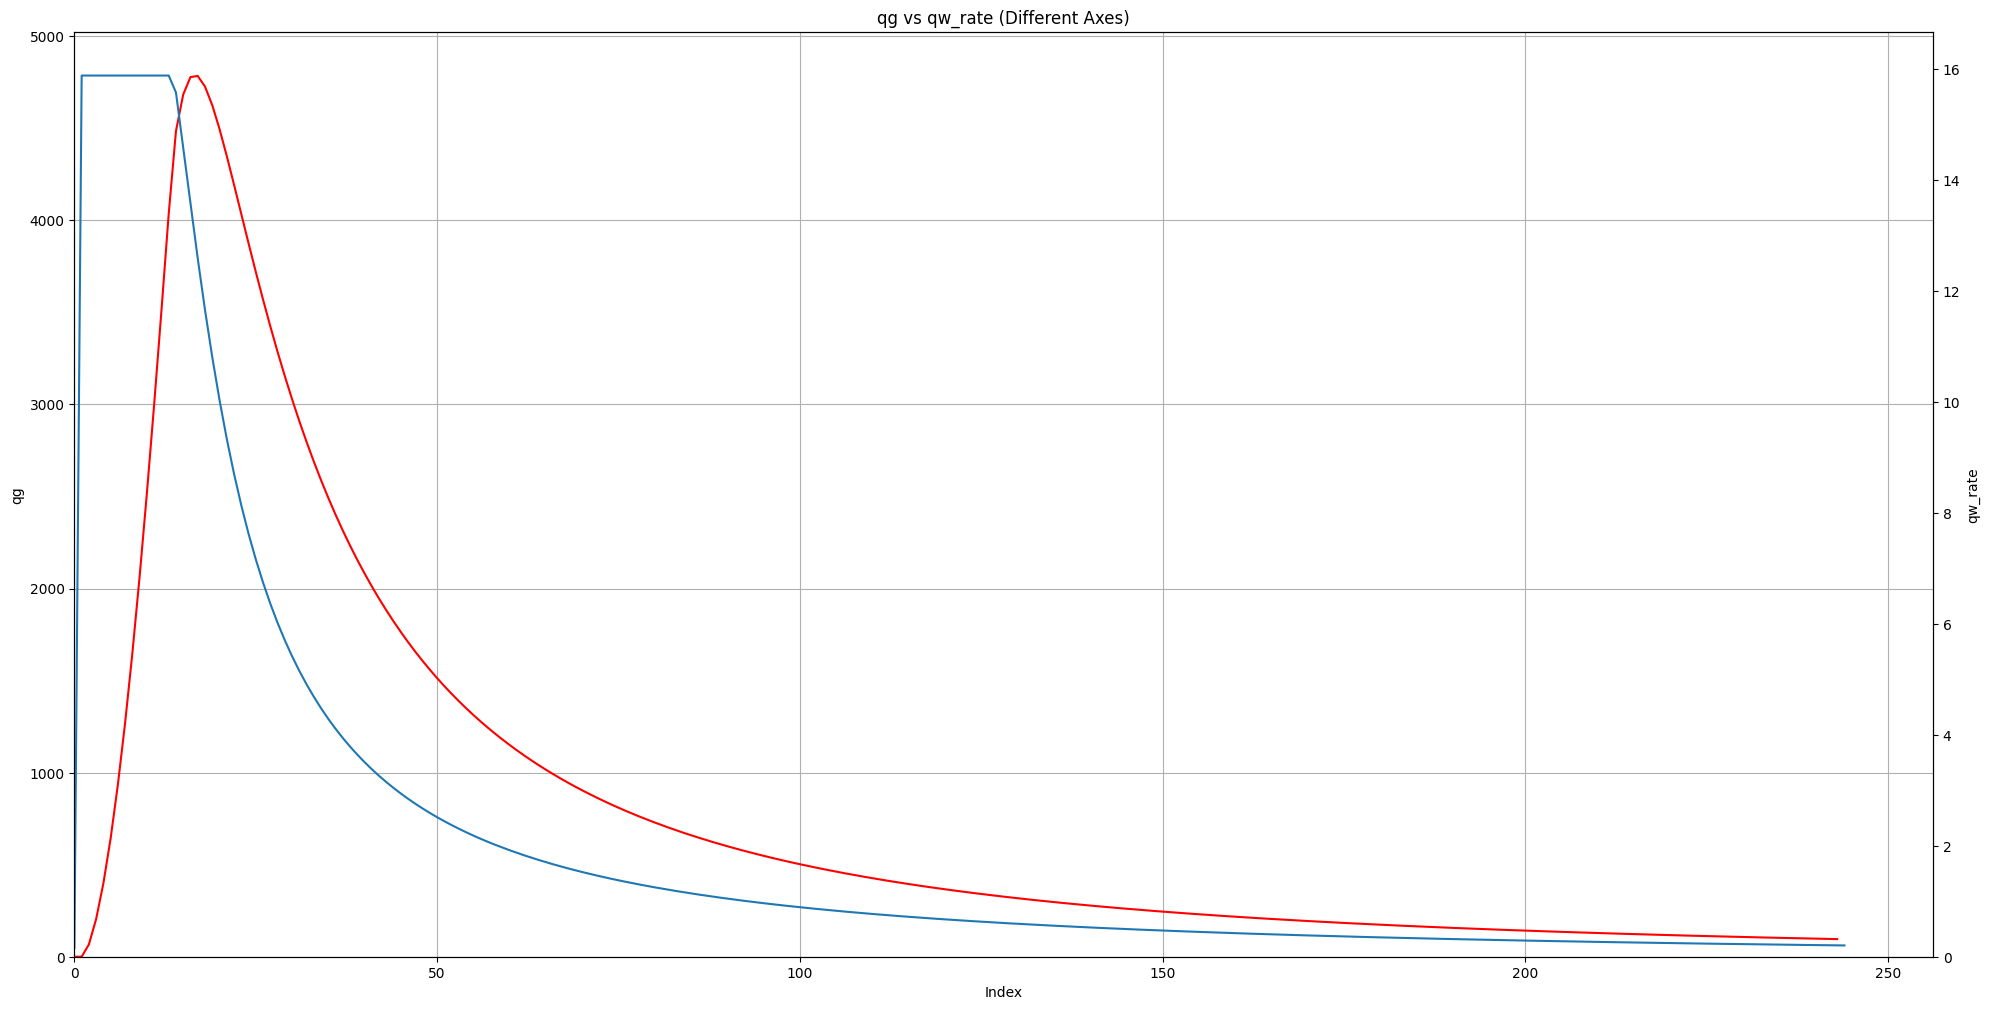

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(20,10))
qg_scmd = np.array(qg_list)/35.31


# First axis (left)
ax1.plot(qg_scmd, label='qg',color='red')
ax1.set_ylabel('qg')
ax1.set_xlabel('Index')
ax1.grid()



# Second axis (right)
ax2 = ax1.twinx()
ax2.plot(np.array(qw_rate_list)/6.298, label='qw_rate')
ax2.set_ylabel('qw_rate')
ax1.set_ylim(bottom=0)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.title("qg vs qw_rate (Different Axes)")
# ax2.grid()
plt.show()

AttributeError: 'list' object has no attribute 'cumsum'

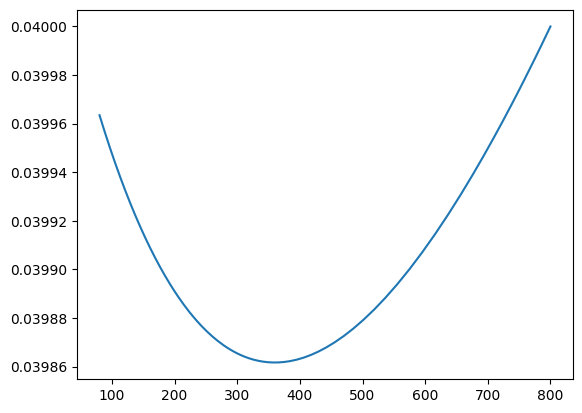

In [ ]:
plt.plot(reservoir_pressure_list[:-1],phi_list)

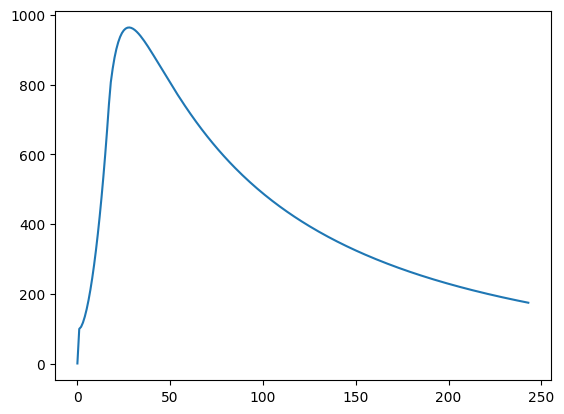

In [ ]:
plt.plot(qtotal_list)
# plt.plot(pawf_list)
# plt.plot(pa_pwf_list)

In [ ]:
pa_pwf_list

[np.float64(4.506840146040085),
 np.float64(468.20826908523196),
 np.float64(476.739796873413),
 np.float64(485.516525246186),
 np.float64(494.563504879767),
 np.float64(503.8892997234257),
 np.float64(513.5041802910554),
 np.float64(523.4191888698174),
 np.float64(533.6460820006629),
 np.float64(544.1973607145404),
 np.float64(555.0863255580421),
 np.float64(566.327147110518),
 np.float64(577.9349490446444),
 np.float64(589.925902436612),
 np.float64(602.3173306805068),
 np.float64(615.1278246695192),
 np.float64(628.3773680972045),
 np.float64(642.0874729015061),
 np.float64(642.4324618967272),
 np.float64(624.3350822880288),
 np.float64(604.5299325635498),
 np.float64(583.6504711671686),
 np.float64(562.7145337040907),
 np.float64(542.2176067784077),
 np.float64(522.3661358021785),
 np.float64(503.28357602021214),
 np.float64(485.0335840858153),
 np.float64(467.64271697056813),
 np.float64(451.1127490091649),
 np.float64(435.42830192423446),
 np.float64(420.5625033553171),
 np.float

In [ ]:
pawf_list

[np.float64(1194.6701578720586),
 np.float64(719.9476615130455),
 np.float64(697.8040465592892),
 np.float64(674.4556970727335),
 np.float64(649.1421817888734),
 np.float64(621.462963712326),
 np.float64(591.1411952081291),
 np.float64(557.9861352350937),
 np.float64(521.8830969973377),
 np.float64(482.7883130146515),
 np.float64(440.72442932097977),
 np.float64(395.7751220125813),
 np.float64(348.0782646069389),
 np.float64(297.81756538794207),
 np.float64(245.21290131389867),
 np.float64(190.50977130972058),
 np.float64(133.96839972301018),
 np.float64(75.85305071576965),
 np.float64(16.422076676527922),
 np.float64(-44.08086747572679),
 np.float64(-110.94669860623094),
 np.float64(-107.8063162654073),
 np.float64(-99.13379607199226),
 np.float64(-85.2858967674872),
 np.float64(-70.44641466653013),
 np.float64(-56.92859712403015),
 np.float64(-45.132414437656166),
 np.float64(-35.069618289167806),
 np.float64(-26.534540545847392),
 np.float64(-19.274127429365365),
 np.float64(-13.058

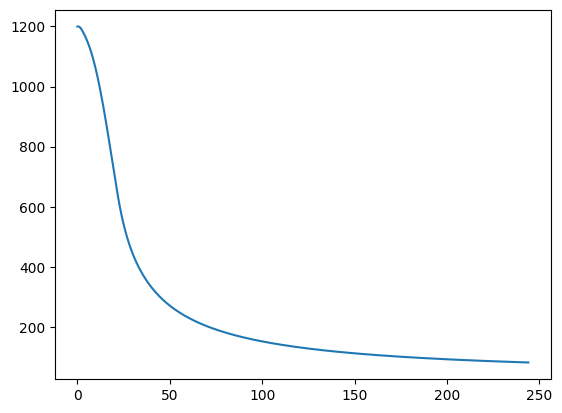

In [ ]:
plt.plot(reservoir_pressure_list)

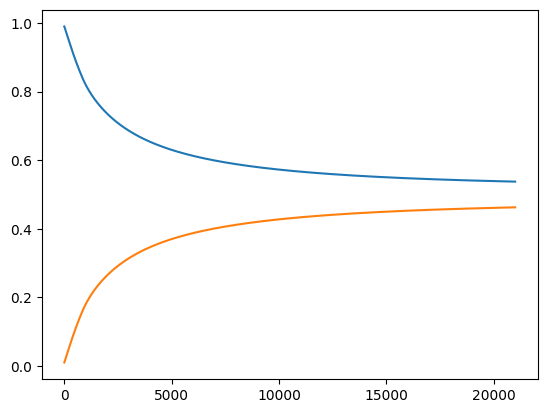

In [ ]:
plt.plot(Sw_list)
plt.plot(sg_list)

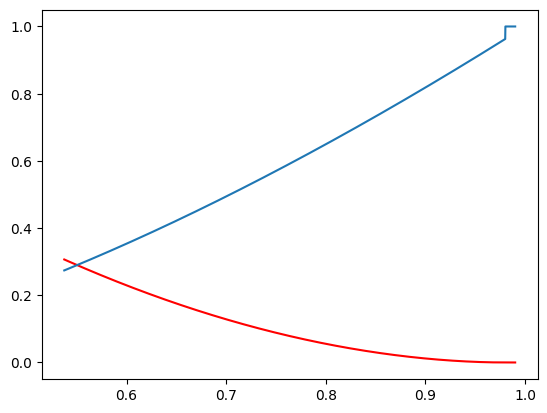

In [ ]:
plt.plot(Sw_list,krg_list,color='red')
plt.plot(Sw_list,krw_list)

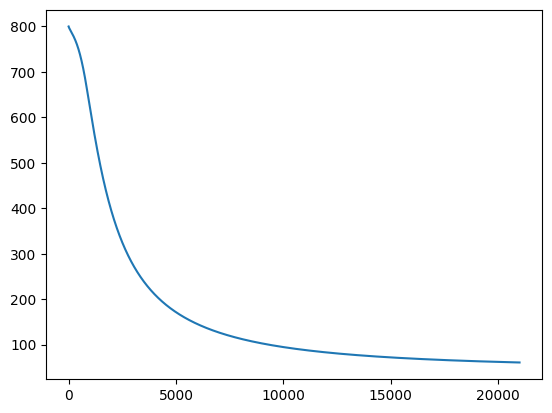

In [ ]:
plt.plot(reservoir_pressure_list)

(0.0, 1259.951000695973)

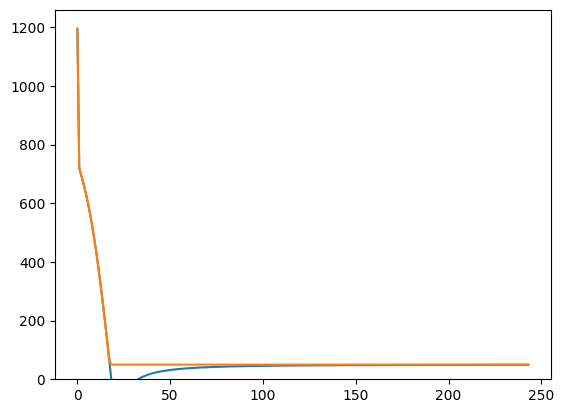

In [ ]:
plt.plot(pawf_list)
plt.plot(wellbore_pressure_list)
plt.ylim(bottom=0)

(0.0, 833.1291067011622)

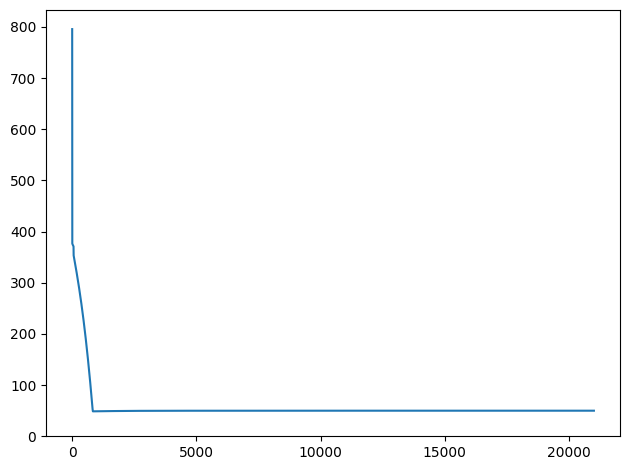

In [ ]:
plt.plot(pawf_list)
plt.tight_layout()
# plt.xlim(left=0)
plt.ylim(bottom=0)

In [ ]:
plt.plot()

TypeError: cg_cal() missing 3 required positional arguments: 'pressure', 'z', and 'delz_delp'

In [ ]:
max(cg_list)

np.float64(0.0026276585992120478)

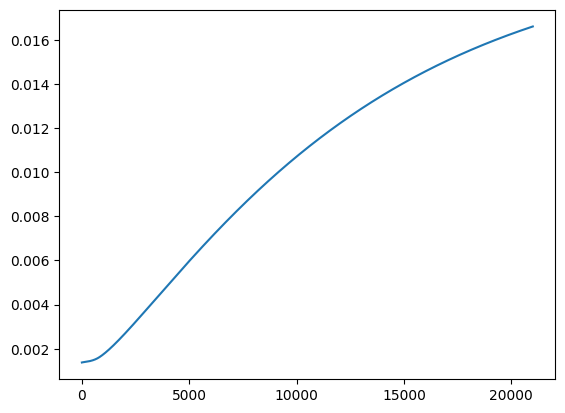

In [ ]:
plt.plot(cg_list)
plt.ticklabel_format(style='plain', axis='both')

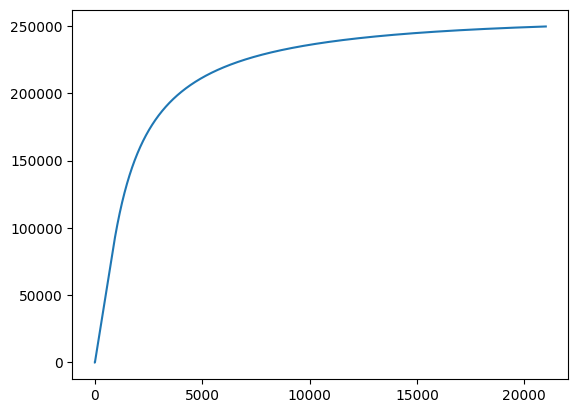

In [ ]:
plt.plot(qw_cum_list)

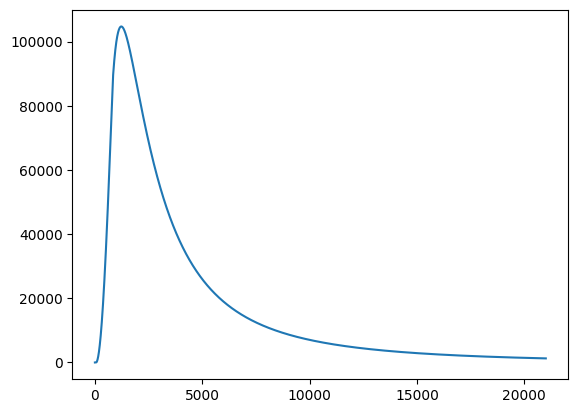

In [ ]:
# plt.plot(pawf_list)
plt.plot(qg_list)

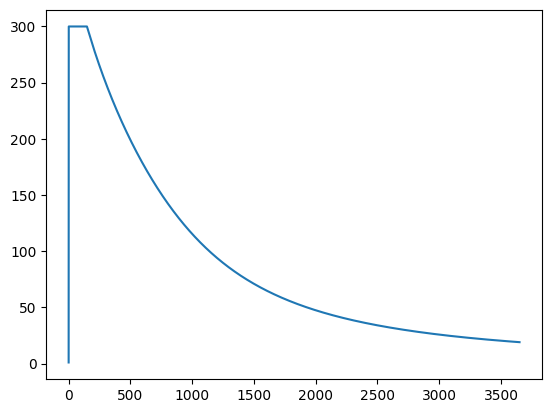

In [ ]:
plt.plot(qw_rate_list)

In [ ]:
12000/30

400.0

In [ ]:
plt.plot()

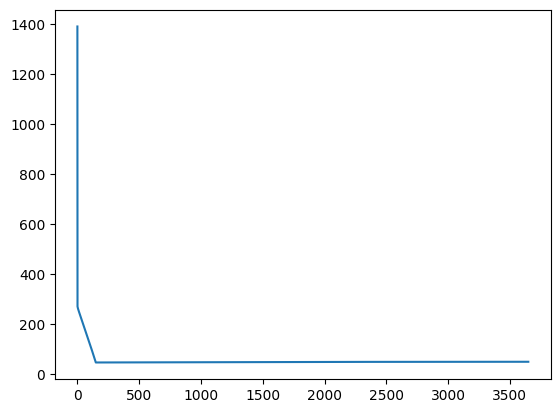

In [ ]:
plt.plot(pawf_list)
# plt.scatter(delta_pa_inflw_list)
# plt.ylim(00,1000)

In [ ]:
for i in range(0,5):
    print(delta_pa_list[i],K_list[i],lamda_rt_list[i])

9.120651754878107 3.0 1.0
4.348990927758146 3.0000379083129705 1.0
3.0040978771039275 3.0067034463017137 1.0
2.808698237230553 3.015286505374294 1.0
2.793425410224573 3.016428965002937 0.9722530367963825


(0.0001, -0.0002)

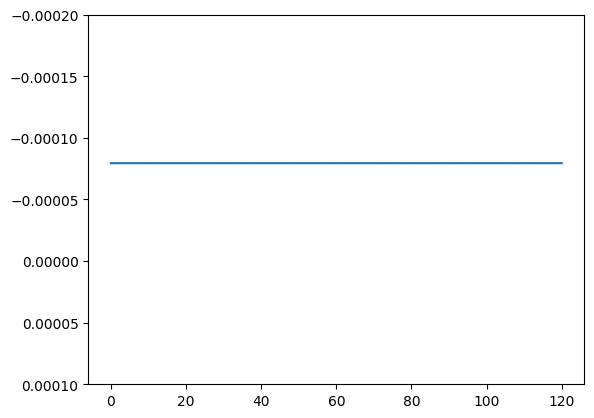

In [ ]:
plt.plot(del_z_del_p_list)
plt.ylim(0.0001,-0.0002)

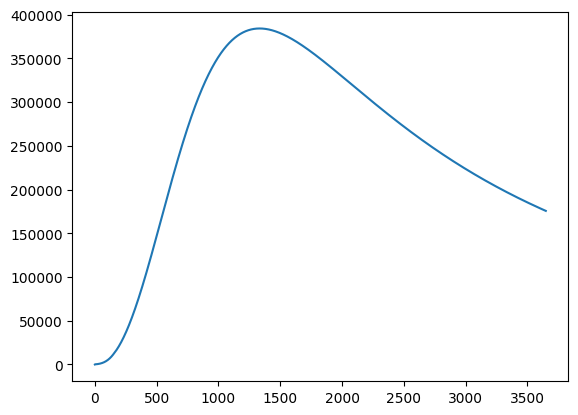

In [ ]:
plt.plot(qg_list)

(0.0, 32791179.68487505)

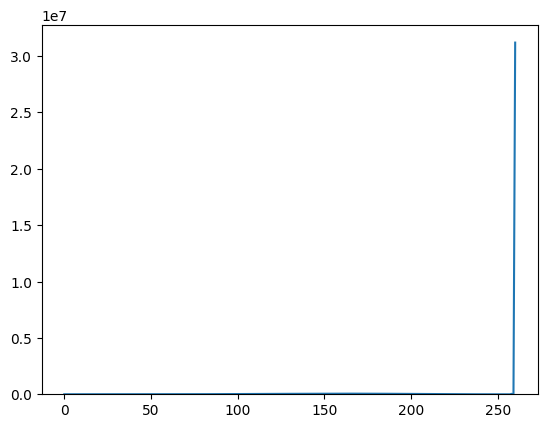

In [ ]:
# plt.plot(cg_list)
plt.plot(qg_scmd_list)
# plt.ylim(0,8000)
plt.ylim(bottom=0)

In [ ]:
z_cal(1476)

NameError: name 'z_cal' is not defined

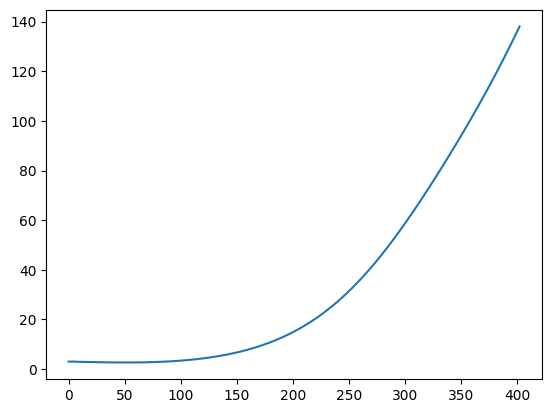

In [ ]:
plt.plot(lamda_t_list)

In [ ]:
plt.plot(cum_qw_list)

NameError: name 'cum_qw_list' is not defined

(0.0, 1.0)

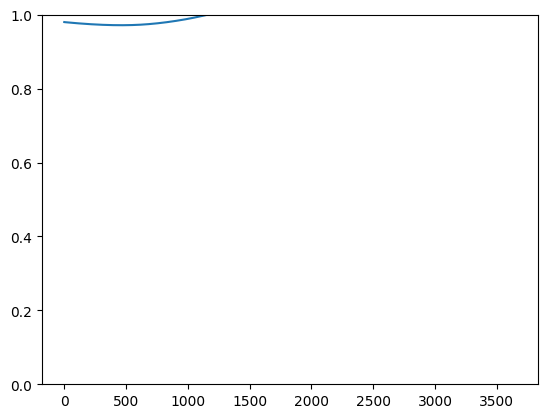

In [ ]:
plt.plot(Sw_list)
plt.ylim(0,1)

In [ ]:
def krg_cal(sw, krge, swc, sgc, ng):
    if sw <= swc:
        return krge
    elif sw >= 1 - sgc:
        return 0
    else:
        return krge * ((1 - sw - sgc) / (1 - swc - sgc)) ** ng

In [ ]:
krg_cal(0.998,0.9,0.2,0,3)

1.4062500000000039e-08

In [ ]:
krw_cal(0.998,1,0.2,0,1.3)

0.996751219461694

In [ ]:
def krw_cal(sw, krwe, swc, sgc, nw):

    if sw <= swc:
        return 0
    elif sw >= 1 - sgc:
        return krwe
    else:
        return krwe * ((sw - swc) / (1 - swc)) ** nw

(0.0, 1220.0)

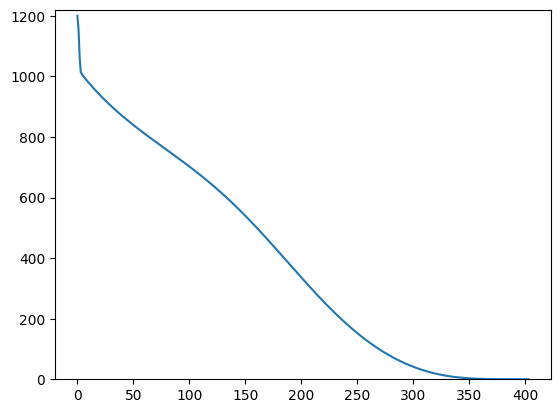

In [ ]:
plt.plot(pressure_list)
plt.ylim(0,1220)

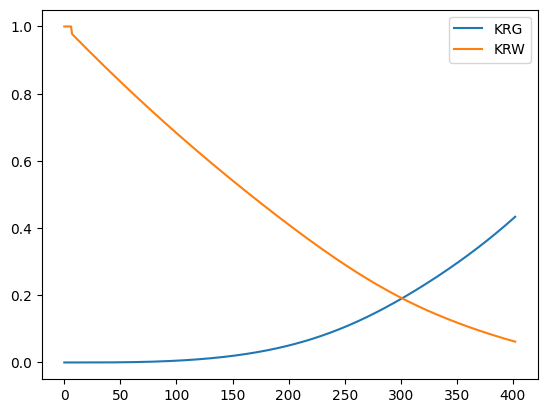

In [ ]:
plt.plot(krg_list,label='KRG')
plt.plot(krw_list,label='KRW')
plt.legend()

(0.0, 100.0)

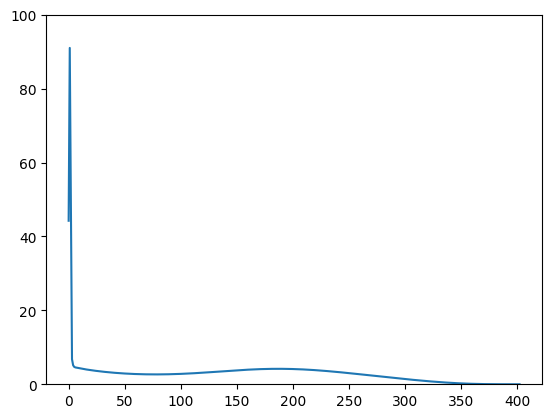

In [ ]:
plt.plot(delta_p_list)
plt.ylim(0,100)

np.float64(0.00037863108147100376)

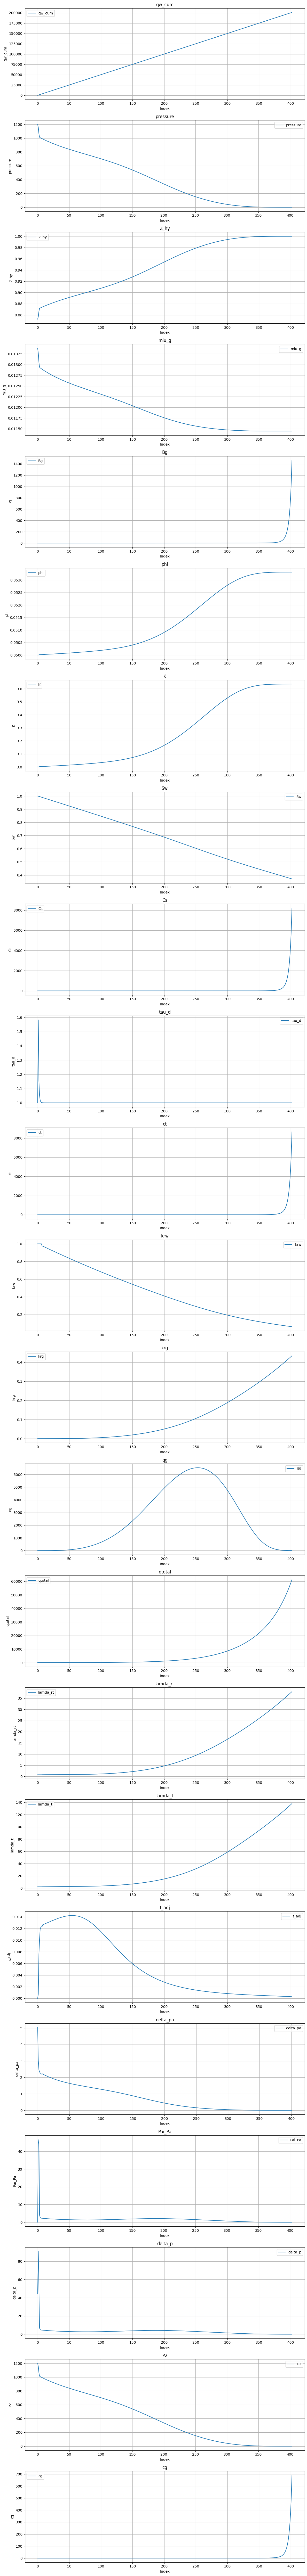

In [ ]:
data_lists = [
    qw_cum_list, pressure_list, Z_hy_list, miu_g_list, Bg_list, phi_list, K_list, Sw_list,
    Cs_list, tau_d_list, ct_list, krw_list, krg_list, qg_scmd_list, qtotal_list,
    lamda_rt_list, lamda_t_list, t_adj_list, delta_pa_list, Pai_Pa_list,delta_p_list, P2_list, cg_list
]

labels = [
    "qw_cum", "pressure", "Z_hy", "miu_g", "Bg", "phi", "K", "Sw", "Cs", "tau_d", "ct",
    "krw", "krg", "qg", "qtotal", "lamda_rt", "lamda_t", "t_adj", "delta_pa","Pai_Pa",
    "delta_p", "P2", "cg"
]

# Plot all lists in different subplots
fig, axes = plt.subplots(nrows=len(data_lists), ncols=1, figsize=(12, 100))

for ax, data, label in zip(axes, data_lists, labels):
    ax.plot(data, label=label)
    # ax.set_xlim(0,110)
    ax.set_title(label)
    ax.set_xlabel('Index')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
delta_pa_inflw_list

[np.float64(668.7757806991385),
 np.float64(668.8216556286837),
 np.float64(668.5909643479806),
 np.float64(668.2471051758355),
 np.float64(668.1882867204004),
 np.float64(668.1415999405461),
 np.float64(668.0973215573995),
 np.float64(683.5734987661085),
 np.float64(685.901495801158),
 np.float64(688.2421179745526),
 np.float64(690.5956444627577),
 np.float64(692.9619552533136),
 np.float64(695.3411374596649),
 np.float64(697.7332836520591),
 np.float64(700.1384892499326),
 np.float64(702.5568509810845),
 np.float64(704.9884665178924),
 np.float64(707.4334343498195),
 np.float64(709.8918537432324),
 np.float64(712.3638247327488),
 np.float64(714.849448124184),
 np.float64(717.3488255017654),
 np.float64(719.862059236928),
 np.float64(722.3892524977167),
 np.float64(724.930509258426),
 np.float64(727.4859343093569),
 np.float64(730.055633266647),
 np.float64(732.6397125821491),
 np.float64(735.2382795533736),
 np.float64(737.8514423334809),
 np.float64(740.4793099413347),
 np.float64(7